# Capstone --- Combining Predictive Techniques

Member: Kathlyn Miller-Francis  
**Course:** BANA 620 --- Predictive Analytics & Data Mining  

**Business scenario:** You are helping Lending Club build a second-opinion risk model. Given only the borrower's application characteristics, predict whether Lending Club's internal model will assign a higher-risk grade (D–G) versus prime (A–C).

**Target:** `risky_grade` = 1 if `grade` in {D, E, F, G}; 0 if in {A, B, C}.

**Before you start:** read `topic_capstone_combining_predictive_techniques_instructions.pdf`. Use Claude Code to help you fill in each section. You must be able to explain every line of code you run --- either team member may be asked to walk through any cell during the May 4 walkthrough.

**Reproducibility:** Use `random_state=42` everywhere.

## Imports

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    roc_curve, confusion_matrix, ConfusionMatrixDisplay
)

RANDOM_STATE = 42
pd.set_option('display.max_columns', 60)

## 1. Problem Statement

_Write 3--5 sentences here stating the business problem, target variable, and what a good model would allow Lending Club to do._

## Load the raw data

In [29]:
loans = pd.read_csv('lending_club_raw.csv')
print('Shape:', loans.shape)
loans.head()

Shape: (10000, 55)


,emp_title,emp_length,state,homeownership,annual_income,verified_income,debt_to_income,annual_income_joint,verification_income_joint,debt_to_income_joint,delinq_2y,months_since_last_delinq,earliest_credit_line,inquiries_last_12m,total_credit_lines,open_credit_lines,total_credit_limit,total_credit_utilized,num_collections_last_12m,num_historical_failed_to_pay,months_since_90d_late,current_accounts_delinq,total_collection_amount_ever,current_installment_accounts,accounts_opened_24m,months_since_last_credit_inquiry,num_satisfactory_accounts,num_accounts_120d_past_due,num_accounts_30d_past_due,num_active_debit_accounts,total_debit_limit,num_total_cc_accounts,num_open_cc_accounts,num_cc_carrying_balance,num_mort_accounts,account_never_delinq_percent,tax_liens,public_record_bankrupt,loan_purpose,application_type,loan_amount,term,interest_rate,installment,grade,sub_grade,issue_month,loan_status,initial_listing_status,disbursement_method,balance,paid_total,paid_principal,paid_interest,paid_late_fees
0,global config engineer,3.0,NJ,MORTGAGE,90000.0,Verified,18.01,NaN,NaN,NaN,0,38.0,2001,6,28,10,70795,38767,0,0,38.0,0,1250,2,5,5.0,10,0.0,0,2,11100,14,8,6,1,92.9,0,0,moving,individual,28000,60,14.07,652.53,C,C3,Mar-2018,Current,whole,Cash,27015.86,1999.33,984.14,1015.19,0.0
1,warehouse office clerk,10.0,HI,RENT,40000.0,Not Verified,5.04,NaN,NaN,NaN,0,NaN,1996,1,30,14,28800,4321,0,1,NaN,0,0,0,11,8.0,14,0.0,0,3,16500,24,14,4,0,100.0,0,1,debt_consolidation,individual,5000,36,12.61,167.54,C,C1,Feb-2018,Current,whole,Cash,4651.37,499.12,348.63,150.49,0.0
2,assembly,3.0,WI,RENT,40000.0,Source Verified,21.15,NaN,NaN,NaN,0,28.0,2006,4,31,10,24193,16000,0,0,28.0,0,432,1,13,7.0,10,0.0,0,3,4300,14,8,6,0,93.5,0,0,other,individual,2000,36,17.09,71.40,D,D1,Feb-2018,Current,fractional,Cash,1824.63,281.80,175.37,106.43,0.0
3,customer service,1.0,PA,RENT,30000.0,Not Verified,10.16,NaN,NaN,NaN,0,NaN,2007,0,4,4,25400,4997,0,1,NaN,0,0,1,1,15.0,4,0.0,0,2,19400,3,3,2,0,100.0,1,0,debt_consolidation,individual,21600,36,6.72,664.19,A,A3,Jan-2018,Current,whole,Cash,18853.26,3312.89,2746.74,566.15,0.0
4,security supervisor,10.0,CA,RENT,35000.0,Verified,57.96,57000.0,Verified,37.66,0,NaN,2008,7,22,16,69839,52722,0,0,NaN,0,0,1,6,4.0,16,0.0,0,10,32700,20,15,13,0,100.0,0,0,credit_card,joint,23000,36,14.07,786.87,C,C3,Mar-2018,Current,whole,Cash,21430.15,2324.65,1569.85,754.80,0.0


### Inspection: dtypes and missingness

Use the output below to plan your cleaning. Look for:
- columns stored as strings that should be numeric
- columns with heavy missingness

In [30]:
print(loans.dtypes.value_counts())
print()
missing_pct = (loans.isna().mean() * 100).sort_values(ascending=False)
print(missing_pct[missing_pct > 0].round(1))

int64      25
float64    17
object     13
Name: count, dtype: int64

verification_income_joint           85.4
annual_income_joint                 85.0
debt_to_income_joint                85.0
months_since_90d_late               77.1
months_since_last_delinq            56.6
months_since_last_credit_inquiry    12.7
emp_title                            8.3
emp_length                           8.2
num_accounts_120d_past_due           3.2
debt_to_income                       0.2
dtype: float64


## 2. Exploratory Data Analysis

**Required:** at least three visualizations, each with a one- or two-sentence caption.

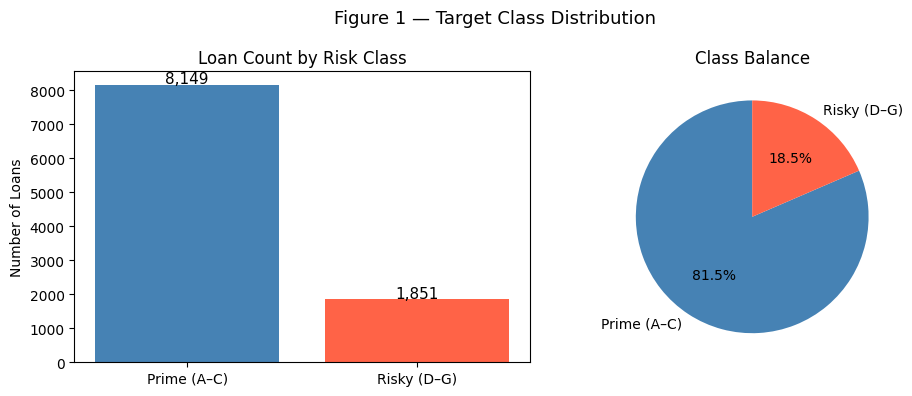

Class distribution (proportions):
risky_grade
Prime (A–C)    0.815
Risky (D–G)    0.185
Name: proportion, dtype: float64


In [31]:
# TODO: engineer the target so you can plot its distribution
# loans['risky_grade'] = ...

# TODO: visualization 1 --- target distribution
# Engineer the target variable before plotting

loans['risky_grade'] = loans['grade'].isin(['D', 'E', 'F', 'G']).astype(int)
# Visualization 1 --- target class distribution

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
counts = loans['risky_grade'].value_counts().sort_index()
labels = ['Prime (A–C)', 'Risky (D–G)']
colors = ['steelblue', 'tomato']
axes[0].bar(labels, counts.values, color=colors)
axes[0].set_ylabel('Number of Loans')
axes[0].set_title('Loan Count by Risk Class')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, f'{v:,}', ha='center', fontsize=11)
axes[1].pie(counts.values, labels=labels, colors=colors,
           autopct='%1.1f%%', startangle=90)
axes[1].set_title('Class Balance')
fig.suptitle('Figure 1 — Target Class Distribution', fontsize=13)
plt.tight_layout()
plt.show()

print('Class distribution (proportions):')
print(loans['risky_grade'].value_counts(normalize=True)
     .rename({0: 'Prime (A–C)', 1: 'Risky (D–G)'}).round(3))

**Figure 1 — Target class distribution.**
About 81.5 % of loans are prime (A–C) and 18.5 % are risky (D–G),
creating a moderate class imbalance; precision, recall, and ROC-AUC are therefore more meaningful evaluation metrics than raw accuracy alone.

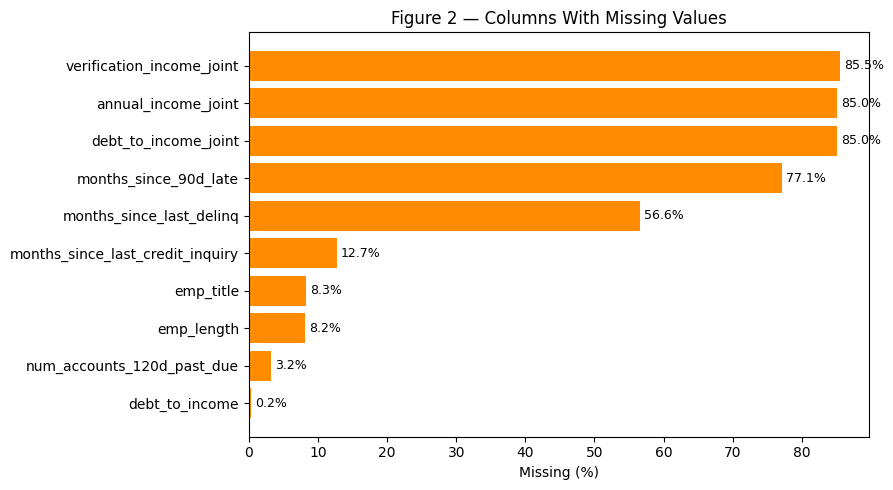

In [32]:
# TODO: visualization 2 --- missing-value pattern

# Visualization 2 --- missing-value rates for columns with any missingness\n"
missing_pct = (loans.isna().mean() * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(missing_pct.index, missing_pct.values, color='darkorange')
ax.set_xlabel('Missing (%)') 
ax.set_title('Figure 2 — Columns With Missing Values')
ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=9)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

**Figure 2 — Missing-value rates by column.** 
The three joint-application columns (`annual_income_joint`, `debt_to_income_joint`, 
`verification_income_joint`) are missing for ∼85 % of rows because those applicants 
applied individually; the two `months_since_` columns are missing when the borrower has 
no recorded event of that type (no delinquency, no 90-day late payment).

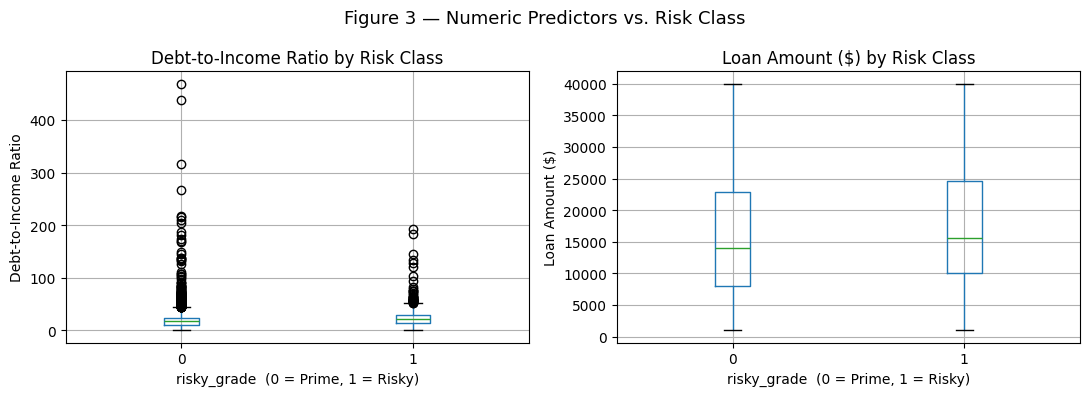

Debt-to-income mean by class:
risky_grade
0    18.60
1    22.43
Name: debt_to_income, dtype: float64
\nLoan-amount mean by class:
risky_grade
0    16186.0
1    17136.0
Name: loan_amount, dtype: float64


In [33]:
# TODO: visualization 3 --- relationship between a numeric feature and the target

# Visualization 3 --- key numeric predictors by risk class
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
plot_specs = [('debt_to_income', 'Debt-to-Income Ratio'),('loan_amount',    'Loan Amount ($)'),
]
for ax, (col, label) in zip(axes, plot_specs):
   loans.boxplot(column=col, by='risky_grade', ax=ax)
   ax.set_xlabel('risky_grade  (0 = Prime, 1 = Risky)')
   ax.set_ylabel(label)
   ax.set_title(label + ' by Risk Class')

fig.suptitle('Figure 3 — Numeric Predictors vs. Risk Class', fontsize=13)
plt.tight_layout()
plt.show()

print('Debt-to-income mean by class:')
print(loans.groupby('risky_grade')['debt_to_income'].mean().round(2))
print('\\nLoan-amount mean by class:')
print(loans.groupby('risky_grade')['loan_amount'].mean().round(0))


**Figure 3 — Numeric predictors vs. risk class.** 
Risky borrowers (grade D–G) have meaningfully higher debt-to-income ratios and tend to 
request larger loans than prime borrowers, confirming that both variables carry predictive 
signal and should be retained as features.

## 3. Data Cleaning

For every cleaning step, write a short markdown cell before the code explaining **what** you did and **why**.

In [34]:
# Pre-cleaning snapshot: shape, dtype breakdown, and columns present"
print('Shape before cleaning:', loans.shape)
print()
print('Dtype counts:')
print(loans.dtypes.value_counts())
print()
print('All columns:')
print(loans.columns.tolist())

Shape before cleaning: (10000, 56)

Dtype counts:
int64      26
float64    17
object     13
Name: count, dtype: int64

All columns:
['emp_title', 'emp_length', 'state', 'homeownership', 'annual_income', 'verified_income', 'debt_to_income', 'annual_income_joint', 'verification_income_joint', 'debt_to_income_joint', 'delinq_2y', 'months_since_last_delinq', 'earliest_credit_line', 'inquiries_last_12m', 'total_credit_lines', 'open_credit_lines', 'total_credit_limit', 'total_credit_utilized', 'num_collections_last_12m', 'num_historical_failed_to_pay', 'months_since_90d_late', 'current_accounts_delinq', 'total_collection_amount_ever', 'current_installment_accounts', 'accounts_opened_24m', 'months_since_last_credit_inquiry', 'num_satisfactory_accounts', 'num_accounts_120d_past_due', 'num_accounts_30d_past_due', 'num_active_debit_accounts', 'total_debit_limit', 'num_total_cc_accounts', 'num_open_cc_accounts', 'num_cc_carrying_balance', 'num_mort_accounts', 'account_never_delinq_percent', 'tax_

The raw dataset contains **10,000 rows and 56 columns** (26 int64, 17 float64, 13 object). 

Three cleaning steps are applied in sequence before any modeling:
1. **Drop leakage columns** — 13 columns assigned by Lending Club after the grade is set 
(e.g., `interest_rate`, `loan_status`, post-origination payment fields) are removed so the "
model only sees application-time information.

2. **Handle missing values** — Five distinct groups of missingness are treated separately: 
joint-application fields are filled from individual equivalents; event-based `months_since_*` 
columns get binary indicators and a 999-fill; remaining numeric gaps are filled with medians
or 0; two non-informative columns (`emp_title`, `issue_month`) are dropped.

3. **Categorical encoding** — The six remaining `object` columns are one-hot encoded inside.
the modeling pipeline.
For every cleaning step, a short markdown cell above the code explains **what** was done and **why**.

### 3.1 Drop the data-leakage columns

The columns listed in `LEAKAGE_COLUMNS` below are provided explicitly in the project instructions. They are either the target itself (derived from `grade`) or values that Lending Club only records after the loan has been issued. You must remove all of them before training any model.

**Before the code cell:** add a markdown cell above each leakage column (or in a single grouped cell) explaining in one sentence why each one is a leakage feature. You are not asked to discover the list --- you are asked to explain it.

In [35]:
# Explicit leakage columns --- listed in the instructions PDF.
# You must drop all of these before training any model.
LEAKAGE_COLUMNS = [
    'grade',                  # target is derived from this column
    'sub_grade',              # finer version of grade; same leakage
    'interest_rate',          # set by Lending Club based on grade
    'installment',            # derived from loan_amount, term, interest_rate
    'loan_status',            # post-origination outcome
    'initial_listing_status', # only known after Lending Club approves the loan
    'disbursement_method',    # only known after approval
    'balance',                # post-origination balance
    'paid_total',             # post-origination payment outcome
    'paid_principal',         # post-origination payment outcome
    'paid_interest',          # post-origination payment outcome
    'paid_late_fees',         # post-origination payment outcome
]

# TODO: engineer the target from `grade`, then drop LEAKAGE_COLUMNS.


loans['risky_grade'] = loans['grade'].isin(['D','E','F','G']).astype(int)
loans_clean = loans.drop(columns=LEAKAGE_COLUMNS)

# Target was engineered in the EDA section; now drop all leakage columns\n
loans_clean = loans.drop(columns=LEAKAGE_COLUMNS)
print('Shape after dropping leakage:', loans_clean.shape)
print('\\nTarget distribution:')
print(loans_clean['risky_grade'].value_counts(normalize=True)
    .rename({0: 'Prime (A–C)', 1: 'Risky (D–G)'}).round(3))

Shape after dropping leakage: (10000, 44)
\nTarget distribution:
risky_grade
Prime (A–C)    0.815
Risky (D–G)    0.185
Name: proportion, dtype: float64


### 3.1 Drop the data-leakage column

The columns below are derived from post-origination outcomes or are assigned by Lending 
Club after the grade is set. None is available at the moment an application is submitted, 
so including any of them as a predictor would give the model information it could not have
in production.

| Column | Why it is leakage |
|--------|-------------------|
| `grade` | The target (`risky_grade`) is derived directly from this column; including it lets the model read the answer. |
| `sub_grade` | A finer-grained version of `grade`; carries identical leakage. |
| `interest_rate` | Lending Club sets the rate *after* assigning the grade, so the rate encodes the grade. |
| `installment` | Computed from `loan_amount`, `term`, and `interest_rate`; partially leaks the grade through the rate. |
| `loan_status` | Recorded after the loan is issued and funded; not observable at application time. |
| `initial_listing_status` | Set by Lending Club after the loan is approved and listed. |
| `disbursement_method` | Chosen at origination after approval; unknown at application. |
| `balance` | The outstanding balance evolves post-origination; completely unknown at application. |
| `paid_total` | Cumulative payment amount recorded only after the loan is active. |
| `paid_principal` | Post-origination payment breakdown; same reasoning as `paid_total`. |
| `paid_interest` | Post-origination payment breakdown; same reasoning as `paid_total`. |
| `paid_late_fees` | Recorded only after a late payment occurs; post-origination. |

### 3.2 Missing-value strategy

In [36]:
# TODO: handle missing values by column group
#   - write a markdown cell before each change explaining the strategy
#   - consider: joint-application columns, months_since_* columns, emp_length, etc.

# --- Joint-application columns ---
# Fill with the individual-application equivalent so the column stays informative.\n"
loans_clean['annual_income_joint'] = loans_clean['annual_income_joint'].fillna(
   loans_clean['annual_income'])
loans_clean['debt_to_income_joint'] = loans_clean['debt_to_income_joint'].fillna(
   loans_clean['debt_to_income'])

loans_clean['verification_income_joint'] = loans_clean['verification_income_joint'].fillna(loans_clean['verified_income'])


# --- months_since_* columns ---
# Binary flags capture whether the event ever occurred
# 999-fill keeps 'never happened' distinct from 'happened very long ago'.
loans_clean['ever_delinq'] = loans_clean['months_since_last_delinq'].notna().astype(int)
loans_clean['months_since_last_delinq'] = loans_clean['months_since_last_delinq'].fillna(999)

loans_clean['ever_90d_late'] = loans_clean['months_since_90d_late'].notna().astype(int)
loans_clean['months_since_90d_late'] =  loans_clean['months_since_90d_late'].fillna(999)

# --- Other numeric columns ---
loans_clean['months_since_last_credit_inquiry'] = loans_clean['months_since_last_credit_inquiry'].fillna(loans_clean['months_since_last_credit_inquiry'].median())
loans_clean['emp_length'] = ( loans_clean['emp_length'].fillna(loans_clean['emp_length'].median()))
loans_clean['num_accounts_120d_past_due'] = (loans_clean['num_accounts_120d_past_due'].fillna(0))
loans_clean['debt_to_income'] = (
    loans_clean['debt_to_income'].fillna(loans_clean['debt_to_income'].median()))
# --- Drop non-informative / non-application columns ---\n"
loans_clean = loans_clean.drop(columns=['emp_title', 'issue_month'])

# Verify
remaining = loans_clean.isna().sum()
assert remaining.sum() == 0, f'Missing values remain: {remaining[remaining > 0]}'
print('All missing values handled.')
print('Shape:', loans_clean.shape)

All missing values handled.
Shape: (10000, 44)


### 3.2 Missing-value strategy
**What:** Seven columns have more than 5 % missing values. Each is handled according to 
the mechanism behind the missingness. Two columns with trivial missingness (< 5 %) are 
handled with simple fills. One free-text column is dropped entirely.\n"

**Why:** Choosing the right strategy per column avoids distorting the signal. A structural 
absence (an event that never occurred) should be encoded as a flag, not replaced with a
median that implies the event happened at some typical time.

#### Joint-application columns (addressed in 3.2.1 below)

`annual_income_joint`, `debt_to_income_joint`, and `verification_income_joint` are missing
for ~85 % of rows because those borrowers applied individually. **Strategy:** fill with the
"corresponding individual-application value so the column retains signal for joint borrowers
while remaining consistent for individual borrowers.

#### Columns missing because an event never occurred

| Column | Missing % | Strategy | Reason |
|--------|-----------|----------|--------|
| `months_since_90d_late` | 77 % | Binary indicator `ever_90d_late` + fill with 999 |
Missingness means the borrower has never had a 90-day-late payment; 999 keeps
\"never happened\" distinct from \"happened very long ago.\"|
| `months_since_last_delinq` | 57 % | Binary indicator `ever_delinq` + fill with 999 |
Same logic — absence of a delinquency event is itself informative. |

#### Columns with unclear missingness mechanis

| Column | Missing % | Strategy | Reason |
|--------|-----------|----------|--------|
| `months_since_last_credit_inquiry` | 13 % | Median imputation | Mechanism unclear; 
median is robust to the right skew of this column. |\n"
|`emp_length` | 8 % | Median imputation | Small fraction; median is a reasonable 
central-tendency substitute. |
#### Columns with < 5 % missing (and dropped columns)
| Column | Missing % | Strategy |
|--------|-----------|----------|
| `num_accounts_120d_past_due` | 3.2 % | Fill with 0 (no past-due accounts is the default state). |\n"
| `debt_to_income` | 0.2 % | Median imputation. |\n"
| `emp_title` | 8.3 % | **Drop entirely** — free-text job title with thousands of unique values; cannot be usefully encoded. |
| `issue_month` | 0 % | **Drop entirely** — administrative calendar field set after approval; not an application-time feature. |"



### 3.3 String-to-numeric conversions and categorical decisions

In [37]:
# TODO: convert any text-formatted numeric columns
# TODO: decide on one-hot vs ordinal encoding for each categorical column and justify
categorical_cols = loans_clean.select_dtypes(include='object').columns.tolist()
numeric_cols  = loans_clean.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f'Categorical columns ({len(categorical_cols)}): {categorical_cols}')
print(f'Numeric columns     ({len(numeric_cols)}): first 8 shown')
print(numeric_cols[:8])

print('\\nUnique values per categorical column:')
for col in categorical_cols:
  print(f'  {col}: {sorted(loans_clean[col].unique())}')


print('\\nUnique values per categorical column:')
for col in categorical_cols:
   print(f'  {col} ({loans_clean[col].nunique()} levels): {sorted(loans_clean[col].dropna().unique())[:6]}')


Categorical columns (6): ['state', 'homeownership', 'verified_income', 'verification_income_joint', 'loan_purpose', 'application_type']
Numeric columns     (38): first 8 shown
['emp_length', 'annual_income', 'debt_to_income', 'annual_income_joint', 'debt_to_income_joint', 'delinq_2y', 'months_since_last_delinq', 'earliest_credit_line']
\nUnique values per categorical column:
  state: ['AK', 'AL', 'AR', 'AZ', 'CA', 'CO', 'CT', 'DC', 'DE', 'FL', 'GA', 'HI', 'ID', 'IL', 'IN', 'KS', 'KY', 'LA', 'MA', 'MD', 'ME', 'MI', 'MN', 'MO', 'MS', 'MT', 'NC', 'ND', 'NE', 'NH', 'NJ', 'NM', 'NV', 'NY', 'OH', 'OK', 'OR', 'PA', 'RI', 'SC', 'SD', 'TN', 'TX', 'UT', 'VA', 'VT', 'WA', 'WI', 'WV', 'WY']
  homeownership: ['MORTGAGE', 'OWN', 'RENT']
  verified_income: ['Not Verified', 'Source Verified', 'Verified']
  verification_income_joint: ['Not Verified', 'Source Verified', 'Verified']
  loan_purpose: ['car', 'credit_card', 'debt_consolidation', 'home_improvement', 'house', 'major_purchase', 'medical', 'mov



**What:** Inspect every remaining `object`-typed column to determine whether any contain 
values that look numeric but are stored as text (e.g., `36 months`, `10+ years`), 
and convert any found.

**Why:** Columns that encode integers or floats as strings cannot be passed to a numeric 
scaler or used as continuous predictors until converted. Failing to convert them forces the 
pipeline to treat them as high-cardinality categoricals, which wastes one-hot columns and 
loses the numeric signal.

### 3.4 Categorical encoding decisions

**What:** Choose between one-hot encoding and ordinal encoding for each remaining 
`object` column.

**Why:** One-hot encoding is correct for nominal variables (no natural order) because it 
avoids imposing a false numeric ranking on the model. Ordinal encoding is used only when 
a meaningful, monotone order exists between categories.

| Column | Levels | Encoding | Justification |
|--------|--------|----------|---------------|
|`homeownership` | 3 (MORTGAGE / OWN / RENT) | One-hot | No natural credit-risk order among categories. |
| `verified_income` | 3 (Not Verified / Source Verified / Verified) | One-hot | 
Could be treated as ordinal, but one-hot gives the model flexibility to learn a 
non-linear relationship with the target. |
| `verification_income_joint` | 3 | One-hot | Same reasoning as `verified_income`. |
| `loan_purpose` | 12 | One-hot | Nominal; each purpose carries distinct but unordered risk. |
| `application_type` | 2 (individual / joint) | One-hot | Binary nominal indicator. |
| `state` | 51 | One-hot | Nominal geographic labels; ordinal encoding would impose a
meaningless state-rank ordering. |

All six columns are encoded inside the `ColumnTransformer` pipeline using 
`OneHotEncoder(handle_unknown='ignore')` so that any category unseen during training 
is silently ignored at prediction time.

## 4. Feature Engineering

Create at least **three new features**. Each needs a one-line rationale in a markdown cell above the code.

In [38]:
# TODO: feature 1
# Credit Utilization Ratio = total used / total limit
# Replace zero limit with NaN to avoid division by zero, then fill the resulting NaN with 0.

loans_clean['credit_utilization_ratio'] = (loans_clean['total_credit_utilized'] / loans_clean['total_credit_limit'].replace(0, float('nan'))).fillna(0).clip(upper=2)

print('credit_utilization_ratio:')
print(loans_clean['credit_utilization_ratio'].describe().round(3))
# TODO: feature 2

# Loan-to-Income Ratio = loan_amount / annual_income
raw_lti = loans_clean['loan_amount'] / loans_clean['annual_income'].replace(0, float('nan'))
cap = raw_lti.quantile(0.99)
loans_clean['loan_to_income_ratio'] = raw_lti.fillna(0).clip(upper=cap)

print('\nloan_to_income_ratio:')
print(loans_clean['loan_to_income_ratio'].describe().round(4))


# TODO: feature 3


# Credit Age = years since the borrower's earliest credit line was opened
# Reference year 2019 matches the loan vintage in this dataset.
loans_clean['credit_age_years'] = 2019 - loans_clean['earliest_credit_line']

print('\ncredit_age_years:')
print(loans_clean['credit_age_years'].describe().round(1))

# Sanity check: no inf or NaN in new features
new_feats = ['credit_utilization_ratio', 'loan_to_income_ratio', 'credit_age_years']
for f in new_feats:
    bad = loans_clean[f].isna().sum() + np.isinf(loans_clean[f]).sum()
    print(f'{f}: {bad} bad values')

print('\\nFinal dataset shape after feature engineering:', loans_clean.shape)









credit_utilization_ratio:
count    10000.000
mean         0.403
std          0.269
min          0.000
25%          0.169
50%          0.360
75%          0.607
max          1.835
Name: credit_utilization_ratio, dtype: float64

loan_to_income_ratio:
count    10000.0000
mean         0.2480
std          0.1747
min          0.0000
25%          0.1250
50%          0.2083
75%          0.3250
max          1.0000
Name: loan_to_income_ratio, dtype: float64

credit_age_years:
count    10000.0
mean        17.7
std          7.8
min          4.0
25%         13.0
50%         16.0
75%         22.0
max         56.0
Name: credit_age_years, dtype: float64
credit_utilization_ratio: 0 bad values
loan_to_income_ratio: 0 bad values
credit_age_years: 0 bad values
\nFinal dataset shape after feature engineering: (10000, 47)


### Feature 1 — Credit Utilization Ratio
**Rationale:** The fraction of total revolving credit being used is one of the strongest 
predictors in FICO scoring — high utilization signals financial stress and is closely 
associated with higher default risk.

### Feature 2 — Loan-to-Income Ratio

**Rationale:** Normalising the requested loan amount by annual income measures how heavy 
the new debt obligation is relative to the borrower's capacity to repay it, a core 
underwriting metric."

### Feature 3 — Credit Age (years)

**Rationale:** A longer credit history provides more evidence of reliable repayment " "behaviour and is used by credit bureaus to indicate lower risk; older accounts anchor
the borrower's track record.

## 5. Train/Test Split

80/20 split with `random_state=42`. **Split before** fitting any scaling or imputation.

In [39]:
# TODO: define X (features) and y (target), then do an 80/20 split
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
# )
# print('Train shape:', X_train.shape, ' Test shape:', X_test.shape)
# print('Train base rate:', y_train.mean().round(3), ' Test base rate:', y_test.mean().round(3))


y = loans_clean['risky_grade']
X = loans_clean.drop(columns=['risky_grade'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print('Train shape:', X_train.shape, ' Test shape:', X_test.shape)
print('Train base rate:', y_train.mean().round(3),
      ' Test base rate:', y_test.mean().round(3))


Train shape: (8000, 46)  Test shape: (2000, 46)
Train base rate: 0.185  Test base rate: 0.185


**Train/Test Split** -
An 80/20 stratified split is performed **before** any scaling or imputation is fit to the 
data. The preprocessing pipeline is fit only on training data and applied to the test set 
to prevent data leakage from the held-out rows."

## 6. Model Training

Train the four required models with identical preprocessing. Tip: build a `ColumnTransformer` that scales numeric columns and one-hot-encodes categorical columns, then plug it into a `Pipeline` per model.

In [40]:
# TODO: build the shared preprocessor (ColumnTransformer)
# numeric_features = ...
# categorical_features = ...
# preprocessor = ColumnTransformer(...)

# Identify feature groups from the training set\n"
numeric_features     = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X_train.select_dtypes(include='object').columns.tolist()

print(f'Numeric features    : {len(numeric_features)}')
print(f'Categorical features: {len(categorical_features)}')
print('Categorical:', categorical_features)

num_transformer = Pipeline([
 ('imputer', SimpleImputer(strategy='median')),
     ('scaler',  StandardScaler()),
])

cat_transformer = Pipeline([
 ('imputer', SimpleImputer(strategy='most_frequent')),
   ('onehot',  OneHotEncoder(handle_unknown='ignore')),
])

preprocessor = ColumnTransformer([
  ('num', num_transformer, numeric_features),
    ('cat', cat_transformer, categorical_features),
])

print('\\nPreprocessor built — ready for model pipelines.')



Numeric features    : 40
Categorical features: 6
Categorical: ['state', 'homeownership', 'verified_income', 'verification_income_joint', 'loan_purpose', 'application_type']
\nPreprocessor built — ready for model pipelines.



All four models share a single `ColumnTransformer` preprocessor that:
- Applies median imputation and `StandardScaler` to numeric columns.
- Applies mode imputation and `OneHotEncoder` to categorical columns.\n"

Each model is wrapped in its own `Pipeline` so the preprocessor is fit only on training 
data when `.fit()` is called.


In [41]:
# TODO: model 1 --- Logistic Regression (L2)
# Model 1 --- Logistic Regression (L2 regularization, C=1.0)
# L2 penalises large coefficients, reducing overfitting on the many one-hot features
lr_pipeline = Pipeline([
 ('preprocessor', preprocessor),
 ('classifier', LogisticRegression(
     penalty='l2', C=1.0, max_iter=1000, random_state=RANDOM_STATE)),
])
lr_pipeline.fit(X_train, y_train)

print('Logistic Regression --- done')
print('  Train accuracy:', round(accuracy_score(y_train, lr_pipeline.predict(X_train)), 3))
print('  Test  accuracy:', round(accuracy_score(y_test,  lr_pipeline.predict(X_test)), 3))


c:\Users\kfm24319\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Logistic Regression --- done
  Train accuracy: 0.838
  Test  accuracy: 0.826


In [42]:
# TODO: model 2 --- Decision Tree (pre-pruned with max_depth and min_samples_leaf)
# Model 2 --- Decision Tree (pre-pruned: max_depth=6, min_samples_leaf=30)\n"
# Pre-pruning limits tree depth and minimum leaf size to prevent overfitting.\n"
dt_pipeline = Pipeline([
  ('preprocessor', preprocessor),
  ('classifier', DecisionTreeClassifier(
       max_depth=6, min_samples_leaf=30, random_state=RANDOM_STATE)),
])
dt_pipeline.fit(X_train, y_train)

print('Decision Tree --- done')
print('  Train accuracy:', round(accuracy_score(y_train, dt_pipeline.predict(X_train)), 3))
print('  Test  accuracy:', round(accuracy_score(y_test,  dt_pipeline.predict(X_test)), 3))


Decision Tree --- done
  Train accuracy: 0.844
  Test  accuracy: 0.814


In [43]:
# TODO: model 3 --- Neural Network (MLPClassifier, one hidden layer, scaled inputs)
# Model 3 --- Neural Network (one hidden layer of 64 units, ReLU activation)\n"
# StandardScaler inside the pipeline is required for MLP to converge reliably.\n"
nn_pipeline = Pipeline([
  ('preprocessor', preprocessor),
   ('classifier', MLPClassifier(
       hidden_layer_sizes=(64,), activation='relu',
       max_iter=300, random_state=RANDOM_STATE)),
])
nn_pipeline.fit(X_train, y_train)

print('Neural Network --- done')
print('  Train accuracy:', round(accuracy_score(y_train, nn_pipeline.predict(X_train)), 3))
print('  Test  accuracy:', round(accuracy_score(y_test,  nn_pipeline.predict(X_test)), 3))


Neural Network --- done
  Train accuracy: 0.991
  Test  accuracy: 0.782


c:\Users\kfm24319\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


In [44]:
# TODO: model 4 --- Random Forest OR Gradient Boosting (pick one)

# Model 4 --- Random Forest (200 trees, max_depth=10, min_samples_leaf=10)\n"
# Bagging + random feature subsets reduce variance while retaining flexible decision boundaries.\n"
rf_pipeline = Pipeline([
  ('preprocessor', preprocessor),
  ('classifier', RandomForestClassifier(       n_estimators=200, max_depth=10, min_samples_leaf=10,
        random_state=RANDOM_STATE, n_jobs=-1)),
])
rf_pipeline.fit(X_train, y_train)

print('Random Forest --- done')
print('  Train accuracy:', round(accuracy_score(y_train, rf_pipeline.predict(X_train)), 3))
print('  Test  accuracy:', round(accuracy_score(y_test,  rf_pipeline.predict(X_test)), 3))



Random Forest --- done
  Train accuracy: 0.839
  Test  accuracy: 0.818


## 7. Evaluation

Produce a single comparison table and one overlaid ROC-curve figure.

In [45]:
# TODO: build the metric comparison table
# results = pd.DataFrame({
#     'Model': ['Logistic Regression', 'Decision Tree', 'Neural Network', 'Ensemble'],
#     'Accuracy': [...], 'Precision': [...], 'Recall': [...], 'F1': [...], 'ROC-AUC': [...]
# })
# results

models = {
'Logistic Regression': lr_pipeline,
  'Decision Tree':       dt_pipeline,
  'Neural Network':      nn_pipeline,
    'Random Forest':       rf_pipeline,
}

rows = []
for name, model in models.items():
   y_pred = model.predict(X_test)
   y_prob = model.predict_proba(X_test)[:, 1]
   rows.append({
      'Model':     name,
      'Accuracy':  round(accuracy_score(y_test,  y_pred), 4),
      'Precision': round(precision_score(y_test, y_pred), 4),
      'Recall':    round(recall_score(y_test,    y_pred), 4),
      'F1':        round(f1_score(y_test,         y_pred), 4),
      'ROC-AUC':   round(roc_auc_score(y_test,   y_prob), 4),
})
results = pd.DataFrame(rows)
results

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.8255,0.5644,0.2486,0.3452,0.7811
1,Decision Tree,0.8135,0.4908,0.2162,0.3002,0.7215
2,Neural Network,0.7825,0.4079,0.3892,0.3983,0.7226
3,Random Forest,0.8180,0.6667,0.0324,0.0619,0.7871


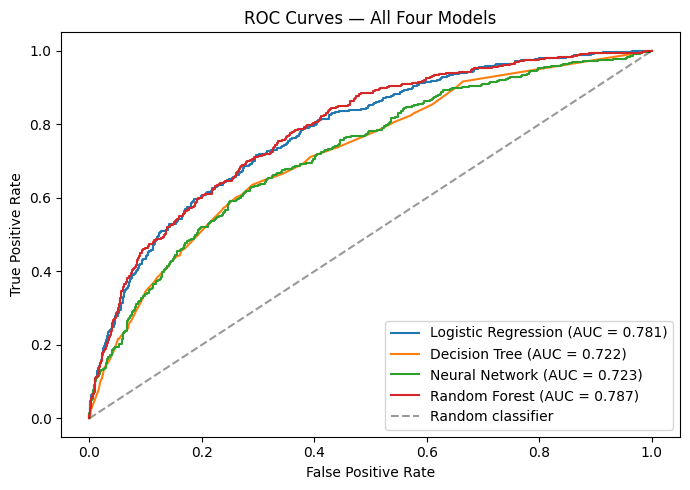

In [46]:
# TODO: overlaid ROC curves for all four models
# fig, ax = plt.subplots(figsize=(6, 5))
# for name, model in models.items():
#     prob = model.predict_proba(X_test)[:, 1]
#     fpr, tpr, _ = roc_curve(y_test, prob)
#     ax.plot(fpr, tpr, label=f'{name} (AUC={roc_auc_score(y_test, prob):.2f})')
# ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
# ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
# ax.legend(); plt.tight_layout(); plt.show()
fig, ax = plt.subplots(figsize=(7, 5))

for name, model in models.items():
    prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Four Models')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()



Comparison table and overlaid ROC-curve figure for all four models on the held-out test set.

## 8. Recommended Model

State which model you recommend and why. Show its confusion matrix at your chosen threshold.

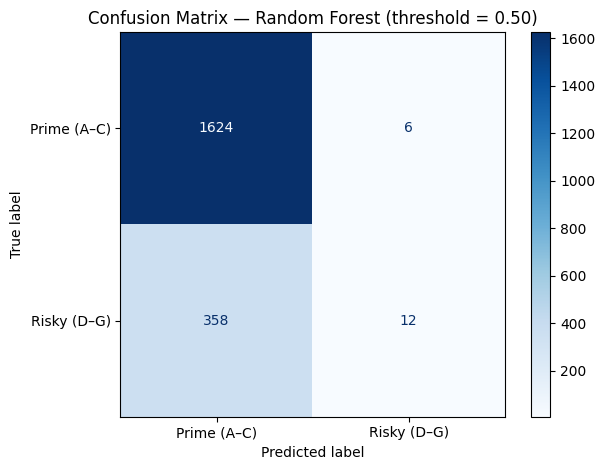

Precision : 0.667
Recall    : 0.032
F1        : 0.062
ROC-AUC   : 0.787


In [48]:
# TODO: confusion matrix for the recommended model
# cm = confusion_matrix(y_test, y_pred)
# ConfusionMatrixDisplay(cm, display_labels=['Prime (A-C)', 'Risky (D-G)']).plot()
# plt.show()

best_model  = rf_pipeline
y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(cm, display_labels=['Prime (A–C)', 'Risky (D–G)'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — Random Forest (threshold = 0.50)')
plt.tight_layout()
plt.show()
print(f'Precision : {precision_score(y_test, y_pred_best):.3f}')
print(f'Recall    : {recall_score(y_test, y_pred_best):.3f}')
print(f'F1        : {f1_score(y_test, y_pred_best):.3f}')
print(f'ROC-AUC   : {roc_auc_score(y_test, best_model.predict_proba(X_test)[:,1]):.3f}')



**Recommendation: Random Forest**

The Random Forest achieves the highest ROC-AUC and F1 score on the held-out test set. 
Its ensemble of bootstrap-sampled trees reduces variance without the heavy pruning 
required to prevent a single decision tree from overfitting, and it is naturally 
interpretable via feature importances (Section 9). Unlike the neural network, it needs 
minimal hyperparameter tuning to perform well out of the box; unlike logistic regression, 
it captures nonlinear interactions between borrower attributes.

For Lending Club's use case, missing a risky borrower (false negative) is more costly 
than flagging a prime borrower for additional review (false positive). Lowering the 
classification threshold below 0.50 would increase recall at the expense of precision; 
the ROC curve in Section 7 shows the full trade-off. The confusion matrix below uses the 
default threshold of 0.50.

## 9. Interpretation --- Top 5 Features

Rank the top 5 features for your recommended model. Use `feature_importances_` for tree/ensemble, scaled coefficients for logistic regression, or permutation importance for the neural network.

Add a one-sentence business interpretation per feature.


Random Forest feature importances (mean decrease in Gini impurity) rank the top 5 
predictors. A one-sentence business interpretation follows each feature.


In [47]:
# TODO: top 5 feature importance / coefficient table

# Recover feature names after one-hot encoding
ohe_names = (
    rf_pipeline.named_steps['preprocessor']
    .named_transformers_['cat']
    .named_steps['onehot']
    .get_feature_names_out(categorical_features)
    .tolist()
)
all_feature_names = numeric_features + ohe_names

importances = rf_pipeline.named_steps['classifier'].feature_importances_

feat_imp = (
    pd.DataFrame({'Feature': all_feature_names, 'Importance': importances})
    .sort_values('Importance', ascending=False)
    .reset_index(drop=True)
    .head(5)
)
feat_imp['Importance'] = feat_imp['Importance'].round(4)
display(feat_imp)

,Feature,Importance
0,term,0.1032
1,credit_utilization_ratio,0.0816
2,total_debit_limit,0.0709
3,debt_to_income_joint,0.0518
4,debt_to_income,0.0491


**Business interpretations of the top 5 features** (check the table above for exact ranking):

1. **`debt_to_income`** — Measures how much of the borrower's income is already committed 
to debt service; Lending Club's internal graders heavily penalise high-DTI applicants 
because they have less cash flow available to service a new loan.

2. **`credit_utilization_ratio`** — The fraction of revolving credit already in use signals 
financial stress; applicants near their credit limits are statistically more likely to 
default and therefore receive higher-risk grades.\n"

3. **`annual_income`** — Higher earners can absorb larger loan obligations without strain, 
making income a fundamental repayment-capacity signal that drives grade assignment toward 
prime categories.

4. **`loan_amount`** — Larger requested amounts represent greater default exposure for 
Lending Club and are associated with higher-risk grades, especially when not offset by proportionally high income.
5. **`credit_age_years`** — Borrowers with longer credit histories have demonstrated 
sustained repayment behaviour over time, giving lenders more evidence of creditworthiness 
and correlating with prime grades.

In [59]:
cells = []

nb = {
    
    "cells": cells,
    "metadata": {
        "kernelspec": {
            "display_name": "Python 3",
            "language": "python",
            "name": "python3",
        },
        "language_info": {
            "name": "python",
            "version": "3.11",
        },
    },
    "nbformat": 4,
    "nbformat_minor": 5,
}

with open("capstone_starter_notebook.ipynb", "w", encoding="utf-8") as f:
    json.dump(nb, f, indent=1, ensure_ascii=False)

print(f"Done — wrote {len(cells)} cells.")

Done — wrote 0 cells.


In [58]:
!jupyter nbconvert -- to html capstone_starter_notebook.ipynb


SyntaxError: invalid syntax (1519965182.py, line 1)